In [2]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')
pd.set_option('display.max_columns',None)

In [3]:
df=pd.read_csv(r'C:\Users\JYOTI_BEHERA\Downloads\archive (12).zip')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,Yes,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,No,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,No,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
cat_cols=[col for col in df.columns if df[col].dtype=='object']
cat_cols

['customerID',
 'gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'TotalCharges',
 'Churn']

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   object 
 1   gender            7043 non-null   object 
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   object 
 4   Dependents        7043 non-null   object 
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   object 
 7   MultipleLines     7043 non-null   object 
 8   InternetService   7043 non-null   object 
 9   OnlineSecurity    7043 non-null   object 
 10  OnlineBackup      7043 non-null   object 
 11  DeviceProtection  7043 non-null   object 
 12  TechSupport       7043 non-null   object 
 13  StreamingTV       7043 non-null   object 
 14  StreamingMovies   7043 non-null   object 
 15  Contract          7043 non-null   object 
 16  PaperlessBilling  7043 non-null   object 


In [7]:
df.isnull().sum()

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

In [8]:
df=df.drop(['customerID'],axis=1)

In [9]:
df['TotalCharges']=pd.to_numeric(df['TotalCharges'],errors='coerce')
df.isnull().sum()

gender               0
SeniorCitizen        0
Partner              0
Dependents           0
tenure               0
PhoneService         0
MultipleLines        0
InternetService      0
OnlineSecurity       0
OnlineBackup         0
DeviceProtection     0
TechSupport          0
StreamingTV          0
StreamingMovies      0
Contract             0
PaperlessBilling     0
PaymentMethod        0
MonthlyCharges       0
TotalCharges        11
Churn                0
dtype: int64

In [10]:
df[np.isnan(df['TotalCharges'])]

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
488,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,No,Yes,Yes,Yes,No,Two year,Yes,Bank transfer (automatic),52.55,NaN,No
753,Male,0,No,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.25,NaN,No
936,Female,0,Yes,Yes,0,Yes,No,DSL,Yes,Yes,Yes,No,Yes,Yes,Two year,No,Mailed check,80.85,NaN,No
1082,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.75,NaN,No
1340,Female,0,Yes,Yes,0,No,No phone service,DSL,Yes,Yes,Yes,Yes,Yes,No,Two year,No,Credit card (automatic),56.05,NaN,No
3331,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,19.85,NaN,No
3826,Male,0,Yes,Yes,0,Yes,Yes,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,25.35,NaN,No
4380,Female,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,Two year,No,Mailed check,20.00,NaN,No
5218,Male,0,Yes,Yes,0,Yes,No,No,No internet service,No internet service,No internet service,No internet service,No internet service,No internet service,One year,Yes,Mailed check,19.70,NaN,No
6670,Female,0,Yes,Yes,0,Yes,Yes,DSL,No,Yes,Yes,Yes,Yes,No,Two year,No,Mailed check,73.35,NaN,No


In [57]:
df=df.drop(labels=df[df['tenure']==0].index,axis=0)
df.isnull().sum()

gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

<Axes: xlabel='Churn', ylabel='count'>

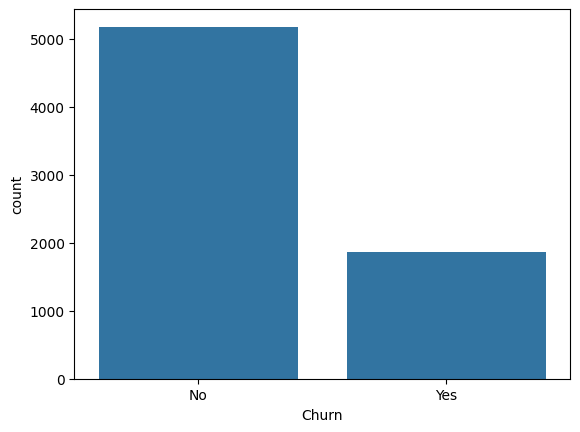

In [11]:
sns.countplot(x='Churn',data=df)

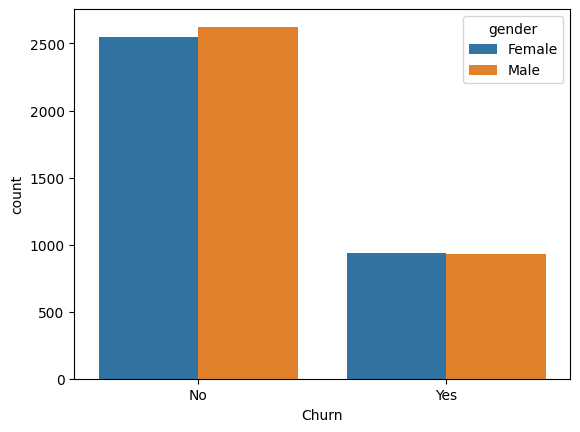

In [12]:
sns.countplot(x='Churn',hue='gender',data=df);

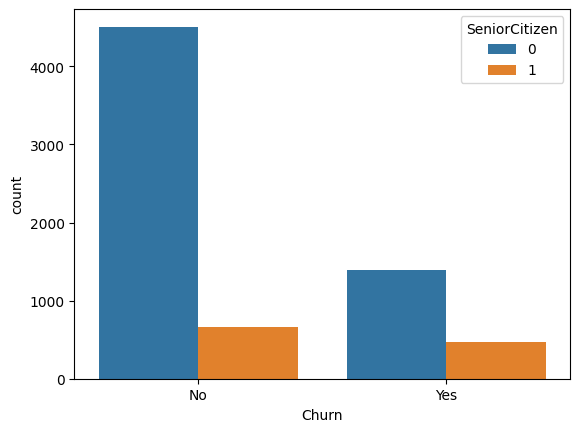

In [13]:
sns.countplot(x='Churn',hue='SeniorCitizen',data=df);

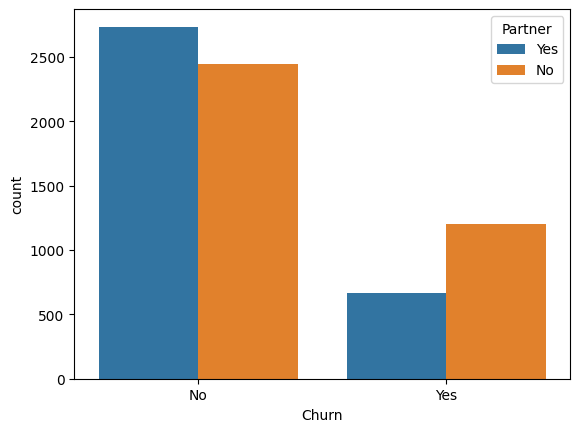

In [14]:
sns.countplot(x='Churn',hue='Partner',data=df);

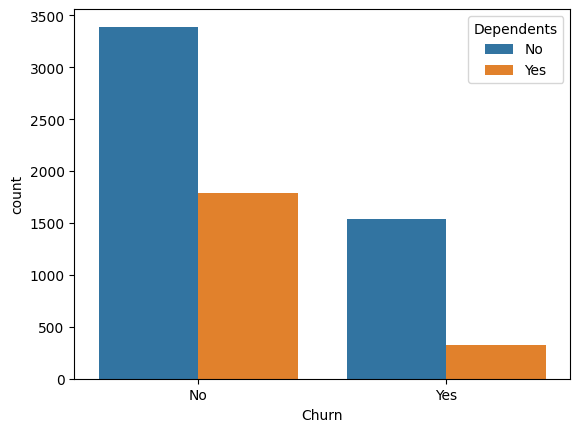

In [15]:
sns.countplot(x='Churn',hue='Dependents',data=df);

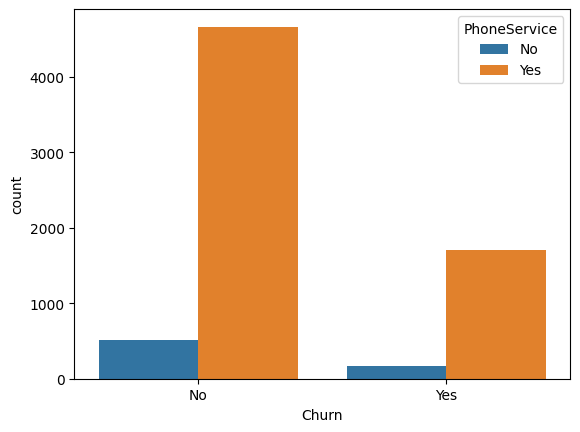

In [16]:
sns.countplot(x='Churn',hue='PhoneService',data=df);

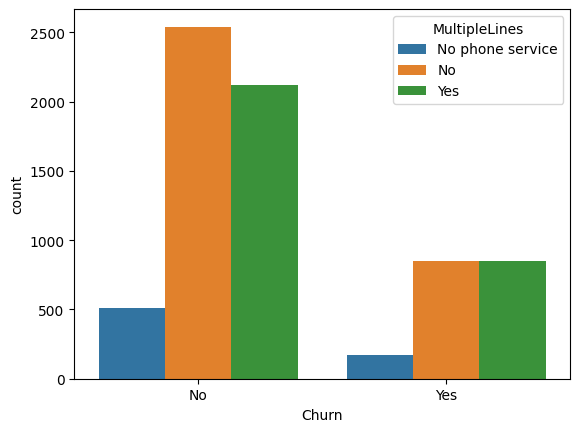

In [17]:
sns.countplot(x='Churn',hue='MultipleLines',data=df);

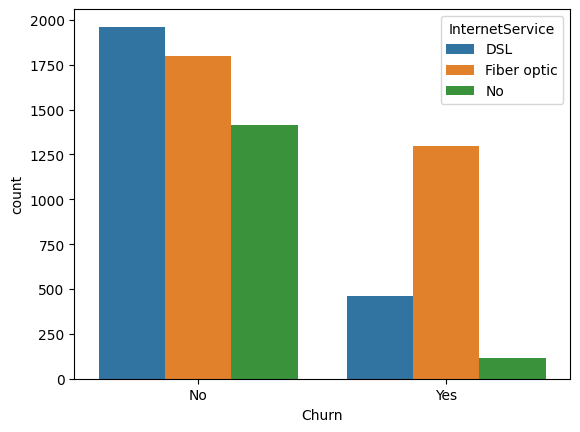

In [18]:
sns.countplot(x='Churn',hue='InternetService',data=df);

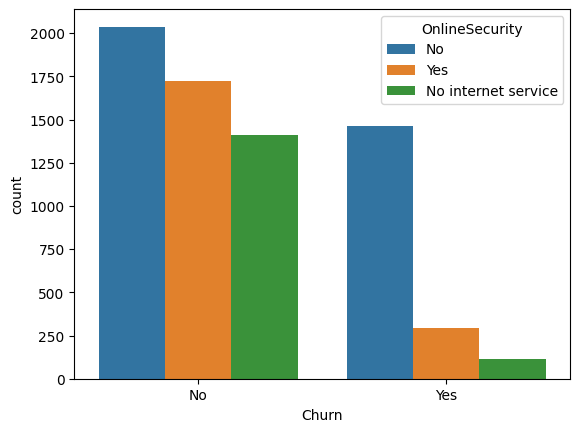

In [19]:
sns.countplot(x='Churn',hue='OnlineSecurity',data=df);

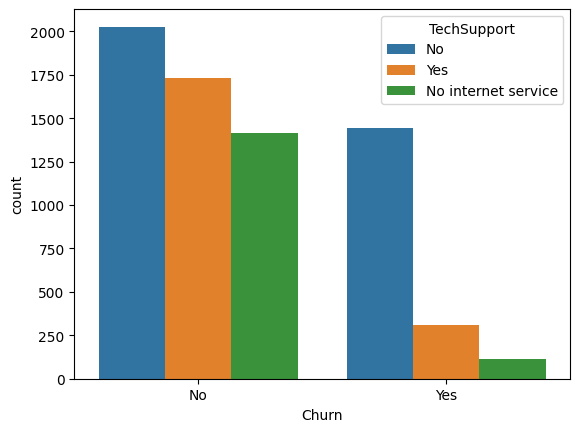

In [20]:
sns.countplot(x='Churn',hue='TechSupport',data=df);

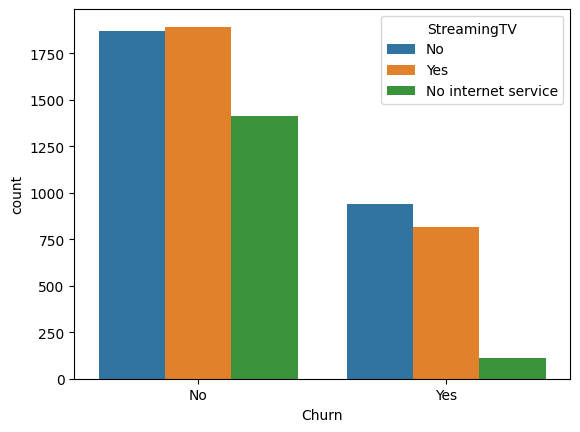

In [21]:
sns.countplot(x='Churn',hue='StreamingTV',data=df);

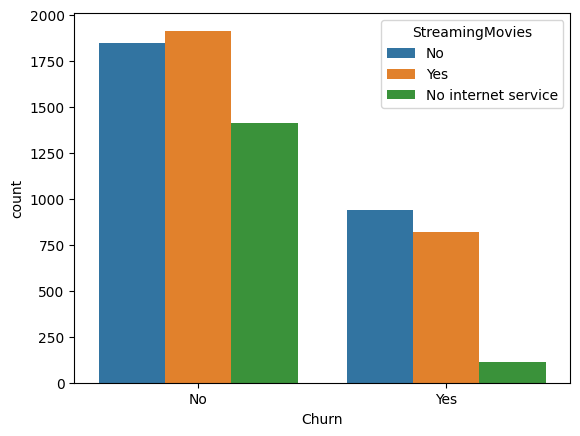

In [22]:
sns.countplot(x='Churn',hue='StreamingMovies',data=df);

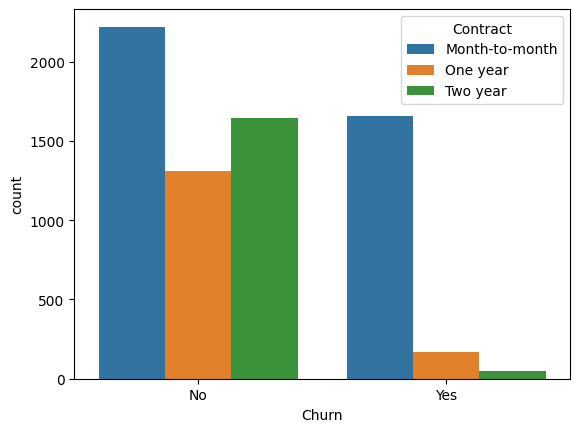

In [23]:
sns.countplot(x='Churn',hue='Contract',data=df);

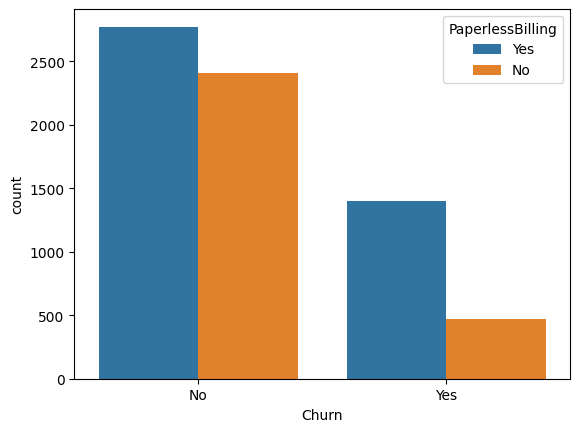

In [24]:
sns.countplot(x='Churn',hue='PaperlessBilling',data=df);

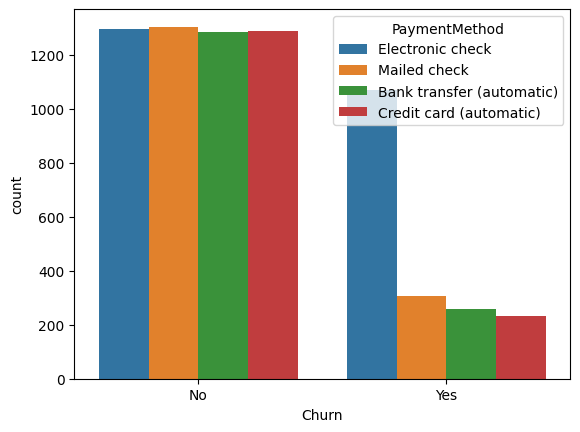

In [25]:
sns.countplot(x='Churn',hue='PaymentMethod',data=df);

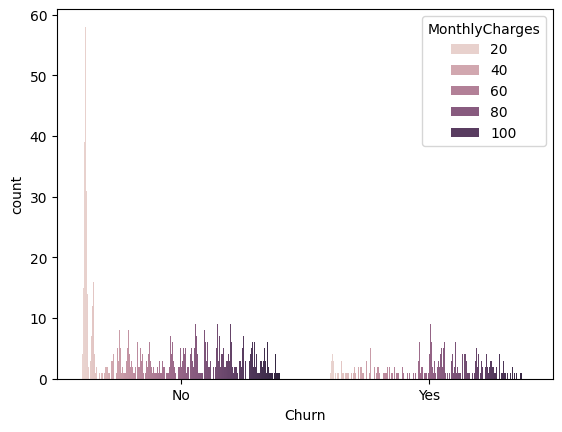

In [26]:
sns.countplot(x='Churn',hue='MonthlyCharges',data=df);

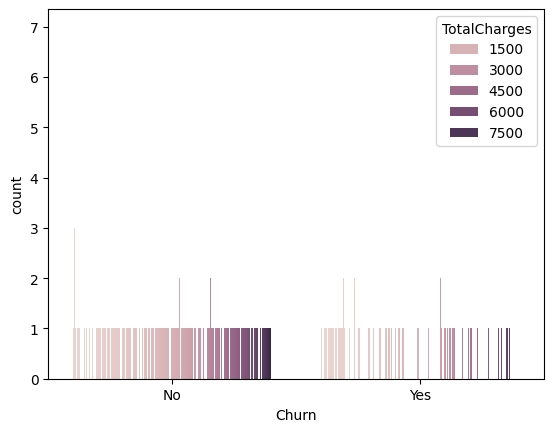

In [27]:
sns.countplot(x='Churn',hue='TotalCharges',data=df);

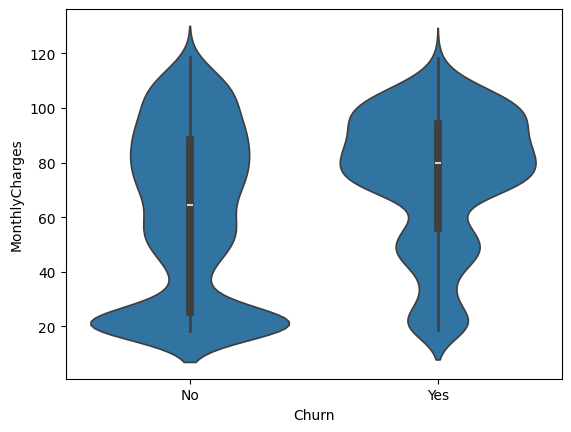

In [28]:
sns.violinplot(x='Churn',y='MonthlyCharges',data=df);

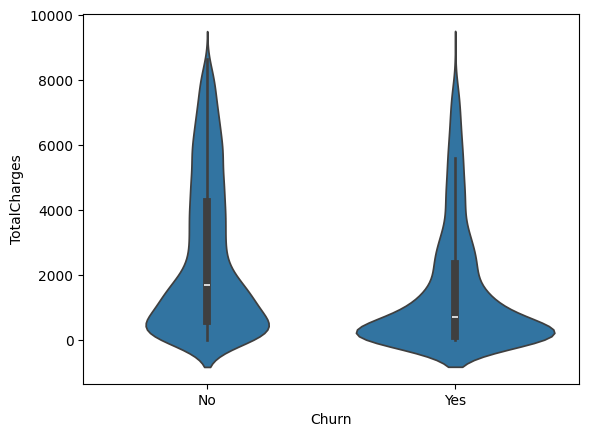

In [29]:
sns.violinplot(x='Churn',y='TotalCharges',data=df);

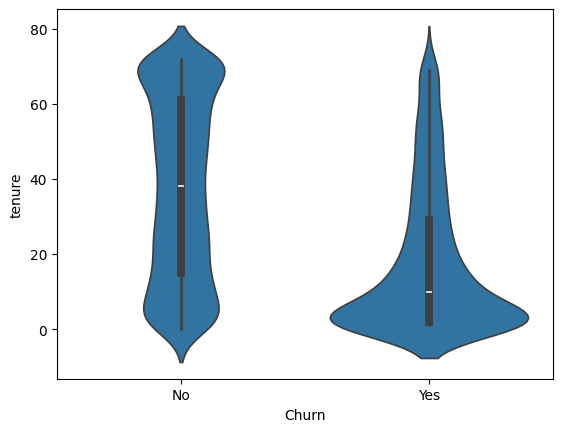

In [30]:
sns.violinplot(x='Churn',y='tenure',data=df);

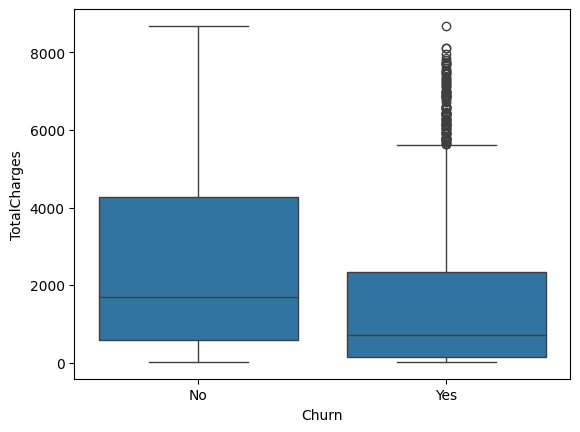

In [31]:
sns.boxplot(x='Churn',y='TotalCharges',data=df);

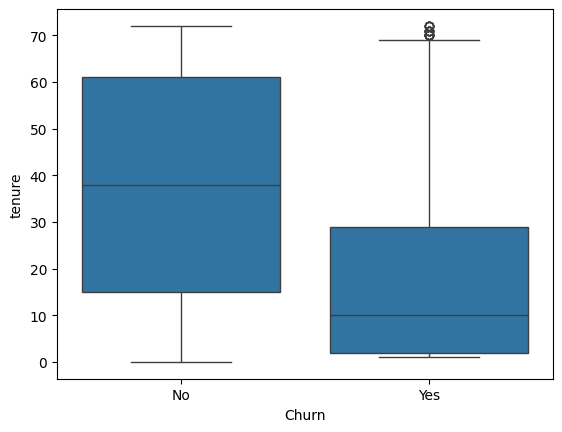

In [32]:
sns.boxplot(x='Churn',y='tenure',data=df);

<Axes: xlabel='TotalCharges', ylabel='Density'>

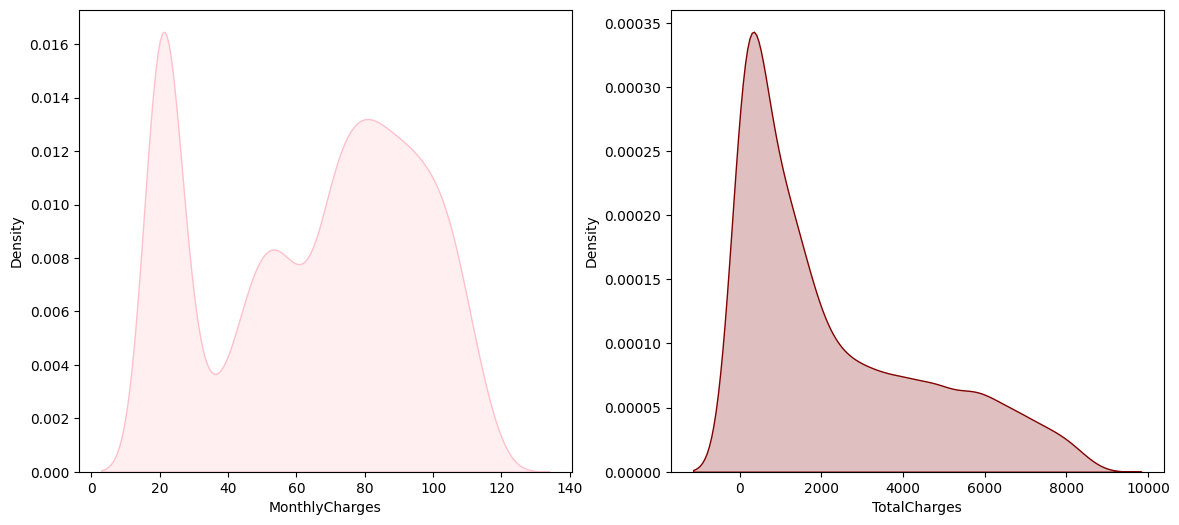

In [33]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.kdeplot(df['MonthlyCharges'],ax=axes[0],color='pink',shade=True)
sns.kdeplot(df['TotalCharges'],ax=axes[1],color='maroon',shade=True)

<Axes: >

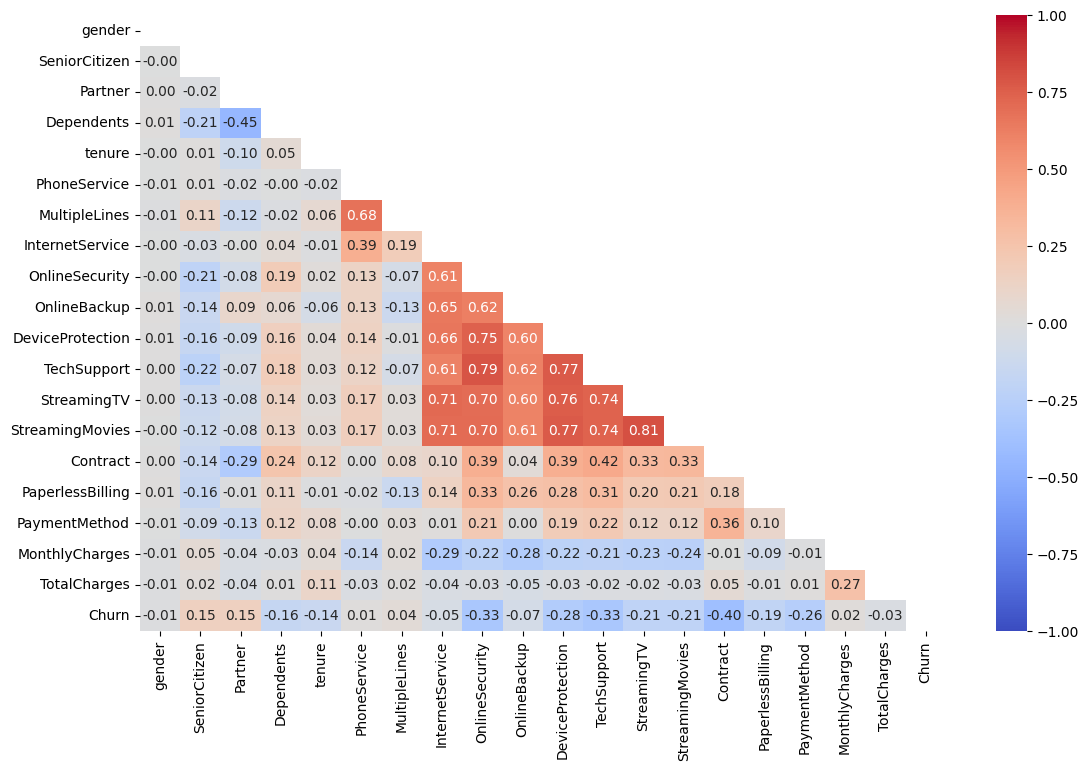

In [34]:
plt.figure(figsize=(13,8))
corr=df.apply(lambda x:pd.factorize(x)[0]).corr()
mask=np.triu(np.ones_like(corr,dtype=bool))
sns.heatmap(corr,mask=mask,cmap='coolwarm',vmax=1,vmin=-1,center=0,annot=True,fmt='.2f')


In [35]:
df.apply(lambda x:pd.factorize(x)[0] if x.dtype!='float64' else x)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,0,29.85,29.85,0
1,1,0,1,0,1,1,1,0,1,1,1,0,0,0,1,1,1,56.95,1889.50,0
2,1,0,1,0,2,1,1,0,1,0,0,0,0,0,0,0,1,53.85,108.15,1
3,1,0,1,0,3,0,0,0,1,1,1,1,0,0,1,1,2,42.30,1840.75,0
4,0,0,1,0,2,1,1,1,0,1,0,0,0,0,0,0,0,70.70,151.65,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
7038,1,0,0,1,65,1,2,0,1,1,1,1,1,1,1,0,1,84.80,1990.50,0
7039,0,0,0,1,21,1,2,1,0,0,1,0,1,1,1,0,3,103.20,7362.90,0
7040,0,0,0,1,26,0,0,0,1,1,0,0,0,0,0,0,0,29.60,346.45,0
7041,1,1,0,0,54,1,2,1,0,1,0,0,0,0,0,0,1,74.40,306.60,1


In [36]:
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,Female,0,Yes,No,1,No,No phone service,DSL,No,Yes,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,Male,0,No,No,34,Yes,No,DSL,Yes,No,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No


In [37]:
cols=[col for col in df.columns if df[col].dtype=='object']
cols

['gender',
 'Partner',
 'Dependents',
 'PhoneService',
 'MultipleLines',
 'InternetService',
 'OnlineSecurity',
 'OnlineBackup',
 'DeviceProtection',
 'TechSupport',
 'StreamingTV',
 'StreamingMovies',
 'Contract',
 'PaperlessBilling',
 'PaymentMethod',
 'Churn']

In [38]:
df.columns

Index(['gender', 'SeniorCitizen', 'Partner', 'Dependents', 'tenure',
       'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity',
       'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV',
       'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod',
       'MonthlyCharges', 'TotalCharges', 'Churn'],
      dtype='object')

In [39]:
print(cat_cols)

['customerID', 'gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges', 'Churn']


In [40]:
cat_cols.remove('customerID')

In [41]:
from sklearn.preprocessing import LabelEncoder
for col in cat_cols:
    le=LabelEncoder()
    df[col]=le.fit_transform(df[col])
df.head(2)

,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,OnlineBackup,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,0,0,1,0,1,0,1,0,0,2,0,0,0,0,0,1,2,29.85,74,0
1,1,0,0,0,34,1,0,0,2,0,2,0,0,0,1,0,3,56.95,3624,0


In [42]:
df['MonthlyCharges']=np.log(df['MonthlyCharges']+1)
df['TotalCharges']=np.log(df['TotalCharges']+1)

<Axes: xlabel='TotalCharges', ylabel='Density'>

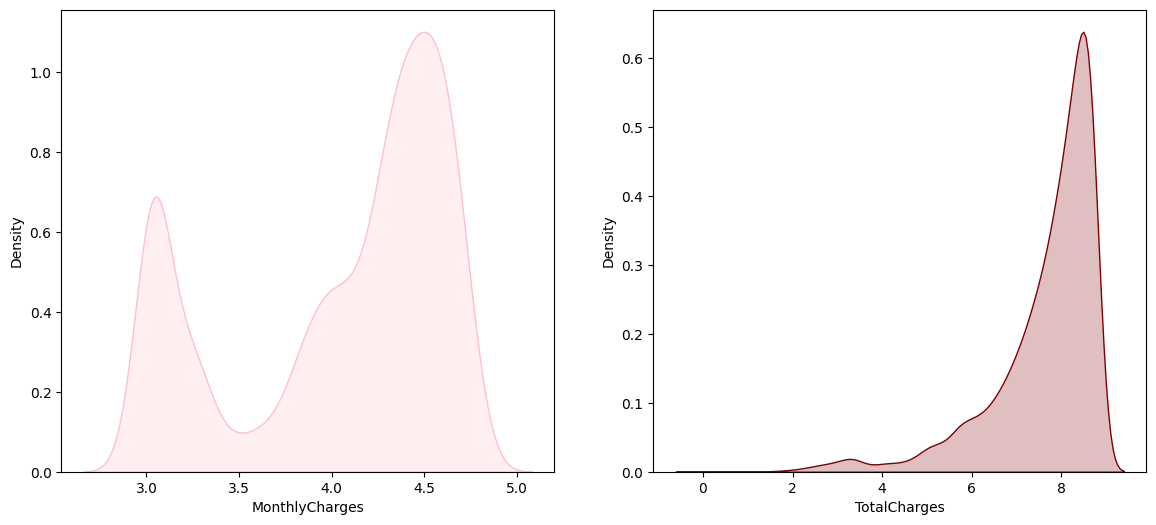

In [43]:
fig,axes=plt.subplots(1,2,figsize=(14,6))
sns.kdeplot(df['MonthlyCharges'],ax=axes[0],color='pink',shade=True)
sns.kdeplot(df['TotalCharges'],ax=axes[1],color='maroon',shade=True)

In [44]:
X=df.drop(columns=['Churn'])
y=df['Churn']
          

In [45]:
from sklearn.model_selection import train_test_split
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.2,random_state=42,stratify=y)

In [46]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import classification_report

In [47]:
model=LogisticRegression()
model.fit(X_train,y_train)

LogisticRegression()

In [48]:
y_pred=model.predict(X_test)

In [49]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.85      0.89      0.87      1035
           1       0.64      0.55      0.59       374

    accuracy                           0.80      1409
   macro avg       0.74      0.72      0.73      1409
weighted avg       0.79      0.80      0.79      1409



In [50]:
from sklearn.ensemble import RandomForestClassifier

In [51]:
model=RandomForestClassifier()
model.fit(X_train,y_train)

RandomForestClassifier()

In [52]:
y_pred=model.predict(X_test)

In [53]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.89      0.86      1035
           1       0.61      0.49      0.54       374

    accuracy                           0.78      1409
   macro avg       0.72      0.69      0.70      1409
weighted avg       0.77      0.78      0.77      1409



In [54]:
!pip install catboost

In [55]:
from catboost import CatBoostClassifier
model=CatBoostClassifier()
model.fit(X_train,y_train)
y_pred=model.predict(X_test)
print(classification_report(y_test,y_pred))

Learning rate set to 0.021554
0:	learn: 0.6775716	total: 196ms	remaining: 3m 16s
1:	learn: 0.6640853	total: 206ms	remaining: 1m 42s
2:	learn: 0.6499020	total: 214ms	remaining: 1m 10s
3:	learn: 0.6376997	total: 221ms	remaining: 55s
4:	learn: 0.6264026	total: 226ms	remaining: 45s
5:	learn: 0.6151591	total: 232ms	remaining: 38.5s
6:	learn: 0.6055758	total: 239ms	remaining: 33.9s
7:	learn: 0.5963254	total: 245ms	remaining: 30.4s
8:	learn: 0.5871290	total: 251ms	remaining: 27.6s
9:	learn: 0.5780919	total: 257ms	remaining: 25.5s
10:	learn: 0.5694217	total: 264ms	remaining: 23.7s
11:	learn: 0.5611662	total: 270ms	remaining: 22.2s
12:	learn: 0.5533359	total: 276ms	remaining: 20.9s
13:	learn: 0.5462912	total: 282ms	remaining: 19.8s
14:	learn: 0.5394370	total: 288ms	remaining: 18.9s
15:	learn: 0.5328081	total: 294ms	remaining: 18.1s
16:	learn: 0.5268470	total: 300ms	remaining: 17.3s
17:	learn: 0.5209229	total: 306ms	remaining: 16.7s
18:	learn: 0.5156625	total: 312ms	remaining: 16.1s
19:	learn: 0

In [56]:
if 'Churn' in cat_cols:
    cat_cols.remove('Churn')

In [57]:
print(cat_cols)

['gender', 'Partner', 'Dependents', 'PhoneService', 'MultipleLines', 'InternetService', 'OnlineSecurity', 'OnlineBackup', 'DeviceProtection', 'TechSupport', 'StreamingTV', 'StreamingMovies', 'Contract', 'PaperlessBilling', 'PaymentMethod', 'TotalCharges']


In [58]:
if 'TotalCharges' in cat_cols:
    cat_cols.remove('TotalCharges')

In [59]:
from catboost import CatBoostClassifier
model=CatBoostClassifier(verbose=False)
model.fit(X_train,y_train,cat_features=cat_cols)

CatBoostClassifier(verbose=False)

In [60]:
y_pred=model.predict(X_test)

In [61]:
print(classification_report(y_test,y_pred))

              precision    recall  f1-score   support

           0       0.83      0.90      0.86      1035
           1       0.64      0.49      0.56       374

    accuracy                           0.79      1409
   macro avg       0.74      0.70      0.71      1409
weighted avg       0.78      0.79      0.78      1409



<Axes: >

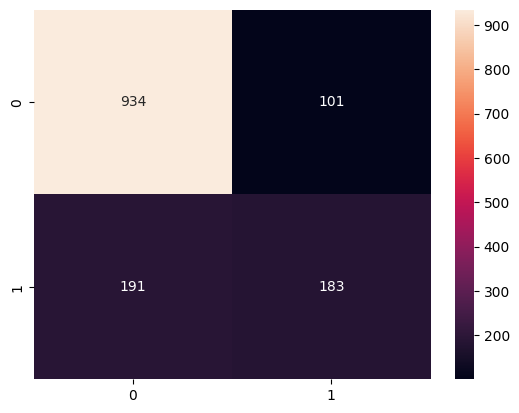

In [62]:
from sklearn.metrics import confusion_matrix
sns.heatmap(confusion_matrix(y_test,y_pred),annot=True,fmt='d')

In [63]:
df.to_csv("churn_final.csv", index=False)

In [1]:
import os

desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
file_path = os.path.join(desktop_path, "churn_final.csv")

df.to_csv(file_path, index=False)

print("Saved at:", file_path)

NameError: name 'df' is not defined

In [2]:
import zipfile
import pandas as pd

zip_path = r'C:\Users\JYOTI_BEHERA\Downloads\archive (12).zip'

with zipfile.ZipFile(zip_path, 'r') as z:
    print(z.namelist())   # andar ka file name dikhayega

['WA_Fn-UseC_-Telco-Customer-Churn.csv']


In [3]:
import pandas as pd

zip_path = r'C:\Users\JYOTI_BEHERA\Downloads\archive (12).zip'

df = pd.read_csv(zip_path, compression='zip')

In [4]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


In [5]:
import os

desktop_path = os.path.join(os.path.expanduser("~"), "Desktop")
file_path = os.path.join(desktop_path, "churn_final.csv")

df.to_csv(file_path, index=False)

print("Saved at:", file_path)

Saved at: C:\Users\JYOTI_BEHERA\Desktop\churn_final.csv
